In [1]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 7.8 MB/s eta 0:00:00


In [ ]:
pip install "numpy<2"

In [2]:
import pmdarima as pm

In [3]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.graphics.tsaplots as sgt
from sklearn.metrics import mean_absolute_percentage_error

In [4]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [5]:
#load the data
df = pd.read_csv("https://raw.githubusercontent.com/christinecheongpuayee88/christinecheong/master/public/notebooks/data/SalesAdv.csv",
                 index_col = 'Time',
                 parse_dates = True)
df.head()

/tmp/ipython-input-1416085851.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("SalesAdv.csv",


,Sales,Adv
Time,,
1,53.8,-0.109
2,53.6,0.000
3,53.5,0.178
4,53.5,0.339
5,53.4,0.373


In [6]:
df.tail()

,Sales,Adv
Time,,
292,58.5,0.195
293,58.3,0.131
294,57.8,0.017
295,57.3,-0.182
296,57.0,-0.262


In [7]:
def lag_arrange(df,name = 'Adv',n_lag = 5):
    # name = 'Gas'
    for i in np.arange(n_lag) + 1:
        # print(i)
        df[name + 'Lag' + str(i)] = df[[name]].shift(i)
    df = df.dropna(how = 'any').reset_index().iloc[:,1:]
    return df

In [8]:
df1 = lag_arrange(df)
df1

,Sales,Adv,AdvLag1,AdvLag2,AdvLag3,AdvLag4,AdvLag5
0,53.1,0.441,0.373,0.339,0.178,0.000,-0.109
1,52.7,0.461,0.441,0.373,0.339,0.178,0.000
2,52.4,0.348,0.461,0.441,0.373,0.339,0.178
3,52.2,0.127,0.348,0.461,0.441,0.373,0.339
4,52.0,-0.180,0.127,0.348,0.461,0.441,0.373
...,...,...,...,...,...,...,...
286,58.5,0.195,0.253,0.204,0.034,-0.204,-0.528
287,58.3,0.131,0.195,0.253,0.204,0.034,-0.204
288,57.8,0.017,0.131,0.195,0.253,0.204,0.034
289,57.3,-0.182,0.017,0.131,0.195,0.253,0.204


<Axes: >

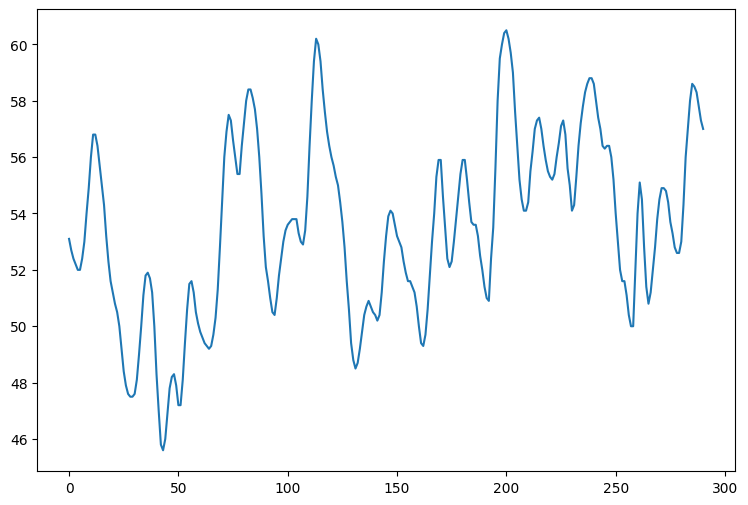

In [9]:
#Y Viz
df1.Sales.plot(figsize = (9,6))

In [10]:
#Stationarity
from statsmodels.tsa.stattools import adfuller
stationarity = adfuller(df1['Sales'])
print('Augmented Dickey Fuller p-value: %F' % stationarity[1])

Augmented Dickey Fuller p-value: 0.070465


<Axes: >

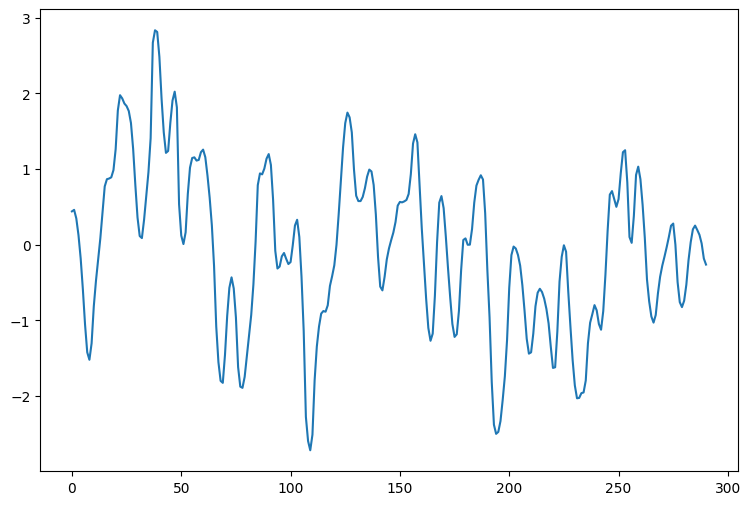

In [11]:
#X Viz
df1.Adv.plot(figsize = (9,6))

In [12]:
#Stationarity
from statsmodels.tsa.stattools import adfuller
stationarity = adfuller(df1['Adv'])
print('Augmented Dickey Fuller p-value: %F' % stationarity[1])

Augmented Dickey Fuller p-value: 0.012116


In [13]:
#Training and test set
test = 10
training_set = df1.iloc[:-test, :]
test_set = df1.iloc[-test:, :]
test_set.head(10)

,Sales,Adv,AdvLag1,AdvLag2,AdvLag3,AdvLag4,AdvLag5
281,54.3,-0.528,-0.740,-0.824,-0.759,-0.493,0.000
282,56.0,-0.204,-0.528,-0.740,-0.824,-0.759,-0.493
283,57.0,0.034,-0.204,-0.528,-0.740,-0.824,-0.759
284,58.0,0.204,0.034,-0.204,-0.528,-0.740,-0.824
285,58.6,0.253,0.204,0.034,-0.204,-0.528,-0.740
286,58.5,0.195,0.253,0.204,0.034,-0.204,-0.528
287,58.3,0.131,0.195,0.253,0.204,0.034,-0.204
288,57.8,0.017,0.131,0.195,0.253,0.204,0.034
289,57.3,-0.182,0.017,0.131,0.195,0.253,0.204
290,57.0,-0.262,-0.182,0.017,0.131,0.195,0.253


In [14]:
training_set

,Sales,Adv,AdvLag1,AdvLag2,AdvLag3,AdvLag4,AdvLag5
0,53.1,0.441,0.373,0.339,0.178,0.000,-0.109
1,52.7,0.461,0.441,0.373,0.339,0.178,0.000
2,52.4,0.348,0.461,0.441,0.373,0.339,0.178
3,52.2,0.127,0.348,0.461,0.441,0.373,0.339
4,52.0,-0.180,0.127,0.348,0.461,0.441,0.373
...,...,...,...,...,...,...,...
276,53.3,0.000,0.280,0.251,0.102,-0.033,-0.158
277,52.8,-0.493,0.000,0.280,0.251,0.102,-0.033
278,52.6,-0.759,-0.493,0.000,0.280,0.251,0.102
279,52.6,-0.824,-0.759,-0.493,0.000,0.280,0.251


**ACF and PACF Plots**

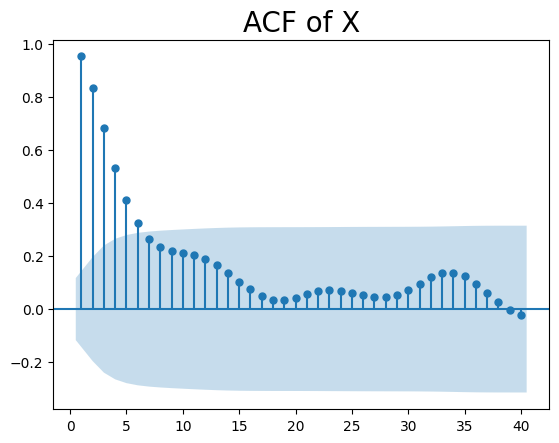

In [15]:
# ACF
sgt.plot_acf(training_set.Adv, lags=40, alpha=0.05, zero=False)
plt.title("ACF of X", size=20)
plt.autoscale(enable=True, axis='y')
plt.show()

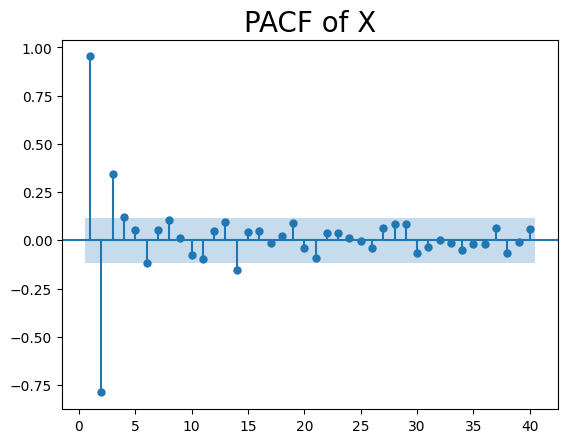

In [ ]:
#PACF
sgt.plot_pacf(training_set.Adv, lags = 40, alpha = 0.05, zero = False , method = ('ols'))
plt.title("PACF of X", size = 20)
plt.autoscale(enable=True, axis='y')
plt.show()

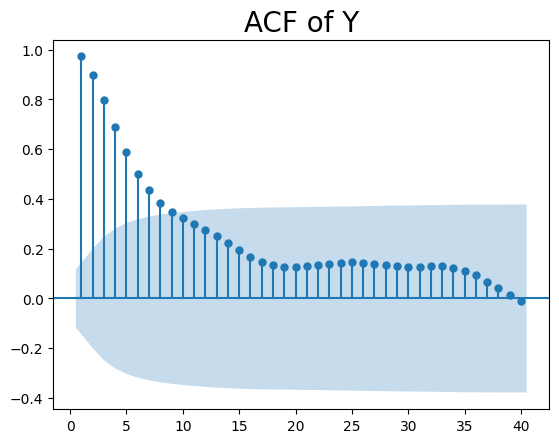

In [ ]:
# ACF
sgt.plot_acf(training_set.Sales, lags=40, alpha=0.05, zero=False)
plt.title("ACF of Y", size=20)
plt.autoscale(enable=True, axis='y')
plt.show()

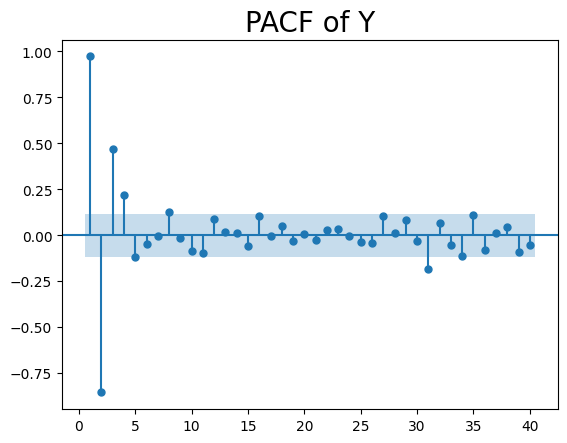

In [ ]:
#PACF
sgt.plot_pacf(training_set.Sales, lags = 40, alpha = 0.05, zero = False , method = ('ols'))
plt.title("PACF of Y", size = 20)
plt.autoscale(enable=True, axis='y')
plt.show()

**ARIMA & SARIMA (using Auto Arima)**

In [ ]:
#ARIMA - take a while to generate results
from pmdarima import auto_arima
model1 = auto_arima(y = training_set.Sales,
                    test='adf', seasonal=True,
                    max_p=3, max_q=3, m=12,
                   stepwise = True)
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  281
Model:               SARIMAX(3, 0, 2)   Log Likelihood                 -89.584
Date:                Wed, 04 Feb 2026   AIC                            193.169
Time:                        06:39:23   BIC                            218.637
Sample:                             0   HQIC                           203.383
                                - 281                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.5917      0.565      2.817      0.005       0.484       2.699
ar.L1          2.1919      0.110     19.915      0.000       1.976       2.408
ar.L2         -1.7404      0.203     -8.559      0.000      -2.139      -1.342
ar.L3          0.5186      0.102      5.108      0.000       0.320       0.718
ma.L1         -0.0917      0.117     -0.786      0.432      -0.320       0.137
ma.L2          0.3070      0.055      5.533      0.000       0.198       0.416
sigma2         0.1082      0.006     16.765      0.000       0.096       0.121
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):               119.75
Prob(Q):                              0.78   Prob(JB):                         0.00
Heteroskedasticity (H):               2.26   Skew:                             0.72
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.86
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
#Predictions (model1)
predictions = pd.Series(model1.predict(n_periods= test)).rename("ARIMA")
predictions.index = test_set.index
predictions.head()

,ARIMA
281,53.492159
282,53.961705
283,54.263837
284,54.364161
285,54.301765


In [ ]:
mape = mean_absolute_percentage_error(test_set.Sales, predictions) * 100
print(f"MAPE for model: {mape:.2f}%")

MAPE for model: 5.75%


**ARIMA and SARIMA (Manual Model Specification)**

In [16]:
# Import the correct ARIMA class
from statsmodels.tsa.arima.model import ARIMA

In [17]:
# ARIMA
model = ARIMA(training_set.Sales, order = (3,0,2))
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Sales   No. Observations:                  281
Model:                 ARIMA(3, 0, 2)   Log Likelihood                 -89.584
Date:                Wed, 04 Feb 2026   AIC                            193.169
Time:                        22:27:17   BIC                            218.637
Sample:                             0   HQIC                           203.383
                                - 281                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         53.4160      0.854     62.515      0.000      51.741      55.091
ar.L1          2.1925      0.110     19.935      0.000       1.977       2.408
ar.L2         -1.7414      0.203     -8.571      0.000      -2.140      -1.343
ar.L3          0.5191      0.101      5.116      0.000       0.320       0.718
ma.L1         -0.0922      0.117     -0.790      0.429      -0.321       0.136
ma.L2          0.3068      0.056      5.528      0.000       0.198       0.416
sigma2         0.1082      0.006     16.765      0.000       0.096       0.121
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):               119.69
Prob(Q):                              0.78   Prob(JB):                         0.00
Heteroskedasticity (H):               2.26   Skew:                             0.72
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.86
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
predictions = results.predict(start=len(training_set), end=len(df1)-1)
predictions.index = test_set.index
display(predictions.head())

,predicted_mean
281,53.492254
282,53.961917
283,54.264155
284,54.364463
285,54.301872


In [ ]:
mape = mean_absolute_percentage_error(test_set.Sales, predictions) * 100
print(f"MAPE for model: {mape:.2f}%")

MAPE for model: 5.75%


In [18]:
# ARIMA
model = ARIMA(training_set.Sales, order = (3,0,0))
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Sales   No. Observations:                  281
Model:                 ARIMA(3, 0, 0)   Log Likelihood                 -99.502
Date:                Wed, 04 Feb 2026   AIC                            209.005
Time:                        22:27:32   BIC                            227.196
Sample:                             0   HQIC                           216.300
                                - 281                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         53.4146      0.786     67.993      0.000      51.875      54.954
ar.L1          2.1970      0.044     49.371      0.000       2.110       2.284
ar.L2         -1.6888      0.079    -21.293      0.000      -1.844      -1.533
ar.L3          0.4640      0.042     11.112      0.000       0.382       0.546
sigma2         0.1163      0.006     17.977      0.000       0.104       0.129
===================================================================================
Ljung-Box (L1) (Q):                   2.59   Jarque-Bera (JB):               188.99
Prob(Q):                              0.11   Prob(JB):                         0.00
Heteroskedasticity (H):               2.30   Skew:                             0.85
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.64
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [19]:
predictions = results.predict(start=len(training_set), end=len(df1)-1)
predictions.index = test_set.index
display(predictions.head())

,predicted_mean
281,53.501459
282,53.927624
283,54.202632
284,54.319789
285,54.310489


In [20]:
mape = mean_absolute_percentage_error(test_set.Sales, predictions) * 100
print(f"MAPE for model: {mape:.2f}%")

MAPE for model: 5.67%


In [21]:
# SARIMA - any seasonal trends?
model = ARIMA(training_set.Sales, order = (3,0,2), seasonal_order = (0, 0, 0, 12))
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Sales   No. Observations:                  281
Model:                 ARIMA(3, 0, 2)   Log Likelihood                 -89.584
Date:                Wed, 04 Feb 2026   AIC                            193.169
Time:                        22:27:58   BIC                            218.637
Sample:                             0   HQIC                           203.383
                                - 281                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         53.4160      0.854     62.515      0.000      51.741      55.091
ar.L1          2.1925      0.110     19.935      0.000       1.977       2.408
ar.L2         -1.7414      0.203     -8.571      0.000      -2.140      -1.343
ar.L3          0.5191      0.101      5.116      0.000       0.320       0.718
ma.L1         -0.0922      0.117     -0.790      0.429      -0.321       0.136
ma.L2          0.3068      0.056      5.528      0.000       0.198       0.416
sigma2         0.1082      0.006     16.765      0.000       0.096       0.121
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):               119.69
Prob(Q):                              0.78   Prob(JB):                         0.00
Heteroskedasticity (H):               2.26   Skew:                             0.72
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.86
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
predictions = results.predict(start=len(training_set), end=len(df1)-1)
predictions.index = test_set.index
display(predictions.head())

,predicted_mean
281,53.492254
282,53.961917
283,54.264155
284,54.364463
285,54.301872


In [ ]:
mape = mean_absolute_percentage_error(test_set.Sales, predictions) * 100
print(f"MAPE for model: {mape:.2f}%")

MAPE for model: 5.75%


**ARIMAX (Using Auto Arima)**

In [22]:
#Exogenous Variables
train_exog = training_set.iloc[:, 1:]
test_exog = test_set.iloc[:, 1:]
print(train_exog)

       Adv  AdvLag1  AdvLag2  AdvLag3  AdvLag4  AdvLag5
0    0.441    0.373    0.339    0.178    0.000   -0.109
1    0.461    0.441    0.373    0.339    0.178    0.000
2    0.348    0.461    0.441    0.373    0.339    0.178
3    0.127    0.348    0.461    0.441    0.373    0.339
4   -0.180    0.127    0.348    0.461    0.441    0.373
..     ...      ...      ...      ...      ...      ...
276  0.000    0.280    0.251    0.102   -0.033   -0.158
277 -0.493    0.000    0.280    0.251    0.102   -0.033
278 -0.759   -0.493    0.000    0.280    0.251    0.102
279 -0.824   -0.759   -0.493    0.000    0.280    0.251
280 -0.740   -0.824   -0.759   -0.493    0.000    0.280

[281 rows x 6 columns]


In [ ]:
print(test_exog)

       Adv  AdvLag1  AdvLag2  AdvLag3  AdvLag4  AdvLag5
281 -0.528   -0.740   -0.824   -0.759   -0.493    0.000
282 -0.204   -0.528   -0.740   -0.824   -0.759   -0.493
283  0.034   -0.204   -0.528   -0.740   -0.824   -0.759
284  0.204    0.034   -0.204   -0.528   -0.740   -0.824
285  0.253    0.204    0.034   -0.204   -0.528   -0.740
286  0.195    0.253    0.204    0.034   -0.204   -0.528
287  0.131    0.195    0.253    0.204    0.034   -0.204
288  0.017    0.131    0.195    0.253    0.204    0.034
289 -0.182    0.017    0.131    0.195    0.253    0.204
290 -0.262   -0.182    0.017    0.131    0.195    0.253


**ARIMAX (using Auto Arima)**

In [ ]:
#ARIMAX - 5 lags (set max p and q)
from pmdarima import auto_arima
model2 = auto_arima(y = training_set.Sales, test='adf',
                   X = train_exog, max_p=3, max_q=3, m=12,
                   seasonal = True,
                   stepwise = True)
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  281
Model:             SARIMAX(1, 0, 1)x(0, 0, 1, 12)   Log Likelihood                 -42.723
Date:                            Wed, 04 Feb 2026   AIC                            107.446
Time:                                    14:20:03   BIC                            147.468
Sample:                                         0   HQIC                           123.497
                                            - 281                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      5.7543      1.767      3.257      0.001       2.292       9.217
Adv           -0.1378      0.118     -1.171      0.242      -0.369       0.093
AdvLag1        0.0979      0.110      0.894      0.372      -0.117       0.313
AdvLag2        0.1396      0.100      1.397      0.162      -0.056       0.335
AdvLag3       -0.4668      0.110     -4.226      0.000      -0.683      -0.250
AdvLag4       -0.9146      0.086    -10.656      0.000      -1.083      -0.746
AdvLag5       -1.0642      0.094    -11.300      0.000      -1.249      -0.880
ar.L1          0.8921      0.033     27.072      0.000       0.828       0.957
ma.L1          0.5766      0.045     12.722      0.000       0.488       0.665
ma.S.L12       0.1641      0.067      2.458      0.014       0.033       0.295
sigma2         0.0890      0.007     12.053      0.000       0.075       0.103
===================================================================================
Ljung-Box (L1) (Q):                   4.62   Jarque-Bera (JB):                54.78
Prob(Q):                              0.03   Prob(JB):                         0.00
Heteroskedasticity (H):               3.14   Skew:                             0.24
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.11
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
#Predictions
predictions = pd.Series(model2.predict(n_periods= test,
                        X = test_exog)).rename("ARIMAX")
predictions.index = test_set.index
predictions.head(1)

,ARIMAX
281,53.922339


In [ ]:
mape = mean_absolute_percentage_error(test_set.Sales, predictions) * 100
print(f"MAPE for model: {mape:.2f}%")

MAPE for model: 5.64%


**ARIMAX (Manual Specification)**

In [23]:
#trainset (how to improve on model?)
model_armax = ARIMA(training_set.Sales, exog = train_exog[['Adv', 'AdvLag1', 'AdvLag2', 'AdvLag3', 'AdvLag4', 'AdvLag5']], order = (3,0,0))
results_armax = model_armax.fit()
results_armax.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Sales   No. Observations:                  281
Model:                 ARIMA(3, 0, 0)   Log Likelihood                 -25.948
Date:                Wed, 04 Feb 2026   AIC                             73.897
Time:                        22:29:40   BIC                            113.919
Sample:                             0   HQIC                            89.948
                                - 281                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         53.2637      0.275    193.429      0.000      52.724      53.803
Adv           -0.0864      0.104     -0.830      0.406      -0.290       0.118
AdvLag1        0.0609      0.082      0.742      0.458      -0.100       0.222
AdvLag2        0.0859      0.077      1.114      0.265      -0.065       0.237
AdvLag3       -0.4719      0.080     -5.875      0.000      -0.629      -0.314
AdvLag4       -0.7196      0.073     -9.794      0.000      -0.864      -0.576
AdvLag5       -1.0410      0.073    -14.192      0.000      -1.185      -0.897
ar.L1          1.6500      0.044     37.337      0.000       1.563       1.737
ar.L2         -0.8796      0.070    -12.548      0.000      -1.017      -0.742
ar.L3          0.1624      0.043      3.808      0.000       0.079       0.246
sigma2         0.0696      0.005     14.378      0.000       0.060       0.079
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):                84.90
Prob(Q):                              0.72   Prob(JB):                         0.00
Heteroskedasticity (H):               3.00   Skew:                             0.39
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.58
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [24]:
predictions = results_armax.predict(start=len(training_set), end=len(df1)-1, exog = test_exog[['Adv', 'AdvLag1', 'AdvLag2', 'AdvLag3', 'AdvLag4', 'AdvLag5']], order = (3,0,0))
predictions.index = test_set.index
display(predictions.head())

,predicted_mean
281,53.769196
282,54.512590
283,54.830984
284,54.782398
285,54.431104


In [25]:
mape_arimax_manual = mean_absolute_percentage_error(test_set.Sales, predictions) * 100
print(f"MAPE for model: {mape_arimax_manual:.2f}%")

MAPE for model: 6.02%


In [ ]:
# try to improve on model

**Try X= 10 Lags (Gas)**

In [26]:
def lag_arrange(df,name = 'Adv',n_lag = 10):
    # name = 'Gas'
    for i in np.arange(n_lag) + 1:
        # print(i)
        df[name + 'Lag' + str(i)] = df[[name]].shift(i)
    df = df.dropna(how = 'any').reset_index().iloc[:,1:]
    return df

In [27]:
df1 = lag_arrange(df)
df1

,Sales,Adv,AdvLag1,AdvLag2,AdvLag3,AdvLag4,AdvLag5,AdvLag6,AdvLag7,AdvLag8,AdvLag9,AdvLag10
0,52.0,-0.588,-0.180,0.127,0.348,0.461,0.441,0.373,0.339,0.178,0.000,-0.109
1,52.4,-1.055,-0.588,-0.180,0.127,0.348,0.461,0.441,0.373,0.339,0.178,0.000
2,53.0,-1.421,-1.055,-0.588,-0.180,0.127,0.348,0.461,0.441,0.373,0.339,0.178
3,54.0,-1.520,-1.421,-1.055,-0.588,-0.180,0.127,0.348,0.461,0.441,0.373,0.339
4,54.9,-1.302,-1.520,-1.421,-1.055,-0.588,-0.180,0.127,0.348,0.461,0.441,0.373
...,...,...,...,...,...,...,...,...,...,...,...,...
281,58.5,0.195,0.253,0.204,0.034,-0.204,-0.528,-0.740,-0.824,-0.759,-0.493,0.000
282,58.3,0.131,0.195,0.253,0.204,0.034,-0.204,-0.528,-0.740,-0.824,-0.759,-0.493
283,57.8,0.017,0.131,0.195,0.253,0.204,0.034,-0.204,-0.528,-0.740,-0.824,-0.759
284,57.3,-0.182,0.017,0.131,0.195,0.253,0.204,0.034,-0.204,-0.528,-0.740,-0.824


In [29]:
#Training and test set
test = 10
training_set = df1.iloc[:-test, :]
test_set = df1.iloc[-test:, :]
test_set

,Sales,Adv,AdvLag1,AdvLag2,AdvLag3,AdvLag4,AdvLag5,AdvLag6,AdvLag7,AdvLag8,AdvLag9,AdvLag10
276,54.3,-0.528,-0.740,-0.824,-0.759,-0.493,0.000,0.280,0.251,0.102,-0.033,-0.158
277,56.0,-0.204,-0.528,-0.740,-0.824,-0.759,-0.493,0.000,0.280,0.251,0.102,-0.033
278,57.0,0.034,-0.204,-0.528,-0.740,-0.824,-0.759,-0.493,0.000,0.280,0.251,0.102
279,58.0,0.204,0.034,-0.204,-0.528,-0.740,-0.824,-0.759,-0.493,0.000,0.280,0.251
280,58.6,0.253,0.204,0.034,-0.204,-0.528,-0.740,-0.824,-0.759,-0.493,0.000,0.280
281,58.5,0.195,0.253,0.204,0.034,-0.204,-0.528,-0.740,-0.824,-0.759,-0.493,0.000
282,58.3,0.131,0.195,0.253,0.204,0.034,-0.204,-0.528,-0.740,-0.824,-0.759,-0.493
283,57.8,0.017,0.131,0.195,0.253,0.204,0.034,-0.204,-0.528,-0.740,-0.824,-0.759
284,57.3,-0.182,0.017,0.131,0.195,0.253,0.204,0.034,-0.204,-0.528,-0.740,-0.824
285,57.0,-0.262,-0.182,0.017,0.131,0.195,0.253,0.204,0.034,-0.204,-0.528,-0.740


In [30]:
#Exogenous Variables
train_exog = training_set.iloc[:, 1:]
test_exog = test_set.iloc[:, 1:]
print(train_exog)

       Adv  AdvLag1  AdvLag2  AdvLag3  AdvLag4  AdvLag5  AdvLag6  AdvLag7  \
0   -0.588   -0.180    0.127    0.348    0.461    0.441    0.373    0.339   
1   -1.055   -0.588   -0.180    0.127    0.348    0.461    0.441    0.373   
2   -1.421   -1.055   -0.588   -0.180    0.127    0.348    0.461    0.441   
3   -1.520   -1.421   -1.055   -0.588   -0.180    0.127    0.348    0.461   
4   -1.302   -1.520   -1.421   -1.055   -0.588   -0.180    0.127    0.348   
..     ...      ...      ...      ...      ...      ...      ...      ...   
271  0.000    0.280    0.251    0.102   -0.033   -0.158   -0.276   -0.424   
272 -0.493    0.000    0.280    0.251    0.102   -0.033   -0.158   -0.276   
273 -0.759   -0.493    0.000    0.280    0.251    0.102   -0.033   -0.158   
274 -0.824   -0.759   -0.493    0.000    0.280    0.251    0.102   -0.033   
275 -0.740   -0.824   -0.759   -0.493    0.000    0.280    0.251    0.102   

     AdvLag8  AdvLag9  AdvLag10  
0      0.178    0.000    -0.109  
1      

In [31]:
print(test_exog)

       Adv  AdvLag1  AdvLag2  AdvLag3  AdvLag4  AdvLag5  AdvLag6  AdvLag7  \
276 -0.528   -0.740   -0.824   -0.759   -0.493    0.000    0.280    0.251   
277 -0.204   -0.528   -0.740   -0.824   -0.759   -0.493    0.000    0.280   
278  0.034   -0.204   -0.528   -0.740   -0.824   -0.759   -0.493    0.000   
279  0.204    0.034   -0.204   -0.528   -0.740   -0.824   -0.759   -0.493   
280  0.253    0.204    0.034   -0.204   -0.528   -0.740   -0.824   -0.759   
281  0.195    0.253    0.204    0.034   -0.204   -0.528   -0.740   -0.824   
282  0.131    0.195    0.253    0.204    0.034   -0.204   -0.528   -0.740   
283  0.017    0.131    0.195    0.253    0.204    0.034   -0.204   -0.528   
284 -0.182    0.017    0.131    0.195    0.253    0.204    0.034   -0.204   
285 -0.262   -0.182    0.017    0.131    0.195    0.253    0.204    0.034   

     AdvLag8  AdvLag9  AdvLag10  
276    0.102   -0.033    -0.158  
277    0.251    0.102    -0.033  
278    0.280    0.251     0.102  
279    0.000    

In [ ]:
#ARIMAX - 10 lags (auto-arima)
from pmdarima import auto_arima
model = auto_arima(y = training_set.Sales, test='adf',
                   X = train_exog, max_p=3, max_q=3, m=12,
                   seasonal = True,
                   stepwise = True)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  276
Model:             SARIMAX(3, 0, 1)x(0, 0, 1, 12)   Log Likelihood                  20.707
Date:                            Wed, 04 Feb 2026   AIC                             -5.414
Time:                                    14:30:13   BIC                             59.753
Sample:                                         0   HQIC                            20.736
                                            - 276                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      3.0690      1.855      1.654      0.098      -0.567       6.705
Adv           -0.0783      0.090     -0.866      0.387      -0.255       0.099
AdvLag1        0.1309      0.073      1.801      0.072      -0.012       0.273
AdvLag2       -0.0290      0.080     -0.364      0.716      -0.185       0.127
AdvLag3       -0.6052      0.090     -6.713      0.000      -0.782      -0.429
AdvLag4       -0.5885      0.093     -6.297      0.000      -0.772      -0.405
AdvLag5       -0.7141      0.083     -8.595      0.000      -0.877      -0.551
AdvLag6       -0.5392      0.093     -5.793      0.000      -0.722      -0.357
AdvLag7       -0.4114      0.095     -4.337      0.000      -0.597      -0.225
AdvLag8        0.0325      0.114      0.285      0.776      -0.191       0.256
AdvLag9        0.0522      0.113      0.461      0.645      -0.170       0.275
AdvLag10      -0.1328      0.087     -1.524      0.128      -0.304       0.038
ar.L1          2.0041      0.165     12.171      0.000       1.681       2.327
ar.L2         -1.5717      0.226     -6.969      0.000      -2.014      -1.130
ar.L3          0.5100      0.096      5.336      0.000       0.323       0.697
ma.L1         -0.4947      0.170     -2.908      0.004      -0.828      -0.161
ma.S.L12       0.1058      0.089      1.183      0.237      -0.070       0.281
sigma2         0.0522      0.004     12.285      0.000       0.044       0.061
===================================================================================
Ljung-Box (L1) (Q):                   3.24   Jarque-Bera (JB):               442.23
Prob(Q):                              0.07   Prob(JB):                         0.00
Heteroskedasticity (H):               3.35   Skew:                             1.17
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# try to improve on model